# Black-Box Model: NARX Neural Network

This notebook implements the third and most flexible level of the model hierarchy:
a Nonlinear AutoRegressive model with eXogenous inputs (NARX) using a shallow
multilayer perceptron (MLP).  No physical structure is assumed — the network
learns input-output dynamics directly from data.

| Level | Model | Structure |
|-------|-------|-----------|
| 1 | First-order SISO | Linear ARX, decoupled |
| 2 | Nonlinear state-space | Physical ODEs, quadratic drag |
| **3** | **NARX MLP** | **No assumed structure** |

## NARX structure

At each timestep $k$, the model predicts the next state from a window of
recent measurements and inputs:

$$\begin{bmatrix} \hat{v}[k+1] \\ \hat{r}[k+1] \end{bmatrix}
= f_{\theta}\!\left(
v[k],\, r[k],\, u[k],\, \delta[k],\;
v[k-1],\, r[k-1],\, u[k-1],\, \delta[k-1],\;
\ldots\right)$$

where $f_\theta$ is an MLP and the window length `n_lags` is a hyperparameter.
The model is MIMO: both surge speed and yaw rate are predicted simultaneously,
allowing it to discover surge–yaw coupling that the structured models assume away.

---
> **Data limitation notice**
>
> With only 130 s of data (1300 samples), the black-box model is operating at the
> edge of what is reasonable.  A shallow MLP with a small lag window is used
> deliberately to limit overfitting.  The primary goal here is to validate the
> workflow and establish a baseline for comparison.  With the larger dataset
> planned for the full paper, deeper architectures and longer lag windows can be
> explored systematically.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score

DATA_CSV = 'usv_step_response_150_280s.csv'
DT       = 0.1
N_LAGS   = 3        # timesteps of history fed to the network
TRAIN_END = 100.0   # seconds — chronological train/test split

## 1. Load data

In [2]:
df    = pd.read_csv(DATA_CSV)
t     = df['time_s'].to_numpy()
u     = df['throttle_norm'].to_numpy()
delta = df['rudder_norm'].to_numpy()
v     = df['speed_mps'].to_numpy()
r     = df['yaw_rate_rps'].to_numpy()

n_train = np.searchsorted(t, TRAIN_END)
print(f'Total samples : {len(t)}  ({t[-1]:.0f} s)')
print(f'Train         : {n_train} samples  (0 – {TRAIN_END:.0f} s)')
print(f'Test          : {len(t)-n_train} samples  ({TRAIN_END:.0f} – {t[-1]:.0f} s)')

Total samples : 1300  (130 s)
Train         : 1000 samples  (0 – 100 s)
Test          : 300 samples  (100 – 130 s)


## 2. Build NARX feature matrix

Each row contains `N_LAGS` consecutive samples of all four signals,
ordered from most recent to oldest.  The target is the state one step ahead.

In [3]:
def build_narx(v, r, u, delta, n_lags):
    """Return feature matrix X and target matrix Y for NARX identification."""
    N = len(v)
    rows = []
    for k in range(n_lags - 1, N - 1):
        row = []
        for lag in range(n_lags):          # lag=0 is most recent
            row += [v[k-lag], r[k-lag], u[k-lag], delta[k-lag]]
        rows.append(row)
    X = np.array(rows)
    Y = np.column_stack([v[n_lags:], r[n_lags:]])   # v[k+1], r[k+1]
    t_X = t[n_lags - 1 : -1]                         # time index for each row
    return X, Y, t_X

X, Y, t_X = build_narx(v, r, u, delta, N_LAGS)

train_mask = t_X <  TRAIN_END
test_mask  = t_X >= TRAIN_END

X_train, Y_train = X[train_mask], Y[train_mask]
X_test,  Y_test  = X[test_mask],  Y[test_mask]

n_features = X.shape[1]
print(f'Features per sample : {n_features}  ({N_LAGS} lags × 4 signals)')
print(f'Training rows       : {len(X_train)}')
print(f'Test rows           : {len(X_test)}')

Features per sample : 12  (3 lags × 4 signals)
Training rows       : 998
Test rows           : 299


## 3. Train MLP

A single hidden layer with 20 neurons.  Both inputs and outputs are standardized
before training to prevent scale differences from affecting convergence.
Early stopping on a held-out validation fraction guards against overfitting
— important given the small dataset.

In [4]:
scaler_X = StandardScaler().fit(X_train)
scaler_Y = StandardScaler().fit(Y_train)

X_train_s = scaler_X.transform(X_train)
Y_train_s = scaler_Y.transform(Y_train)
X_test_s  = scaler_X.transform(X_test)

mlp = MLPRegressor(
    hidden_layer_sizes=(20,),
    activation='relu',
    max_iter=3000,
    random_state=42,
    early_stopping=True,
    validation_fraction=0.15,
    n_iter_no_change=50,
    verbose=False
)
mlp.fit(X_train_s, Y_train_s)

print(f'Converged after {mlp.n_iter_} iterations')
print(f'Best validation loss: {mlp.best_validation_score_:.6f}')

# One-step prediction on test set
Y_pred_s = mlp.predict(X_test_s)
Y_pred   = scaler_Y.inverse_transform(Y_pred_s)

r2_1step_v = r2_score(Y_test[:, 0], Y_pred[:, 0])
r2_1step_r = r2_score(Y_test[:, 1], Y_pred[:, 1])
print(f'\nOne-step prediction on test set:')
print(f'  Speed    R² = {r2_1step_v:.4f}')
print(f'  Yaw rate R² = {r2_1step_r:.4f}')

Converged after 151 iterations
Best validation loss: 0.992320

One-step prediction on test set:
  Speed    R² = 0.9269
  Yaw rate R² = 0.8763


## 4. Closed-loop simulation

One-step prediction is an optimistic metric because it uses measured (not predicted)
state history.  A more honest evaluation drives the model with its own predictions
as past states, propagating errors forward — the same evaluation used for the
structured models.

In [5]:
def simulate_narx(mlp, scaler_X, scaler_Y, v, r, u, delta, n_lags):
    """Simulate NARX model on full sequence, seeding history from measurements."""
    v_sim = list(v[:n_lags])
    r_sim = list(r[:n_lags])

    for k in range(n_lags - 1, len(t) - 1):
        row = []
        for lag in range(n_lags):
            row += [v_sim[k - lag], r_sim[k - lag], u[k - lag], delta[k - lag]]
        x_s  = scaler_X.transform([row])
        y_s  = mlp.predict(x_s)
        y    = scaler_Y.inverse_transform(y_s)[0]
        v_sim.append(y[0])
        r_sim.append(y[1])

    return np.array(v_sim), np.array(r_sim)

v_sim, r_sim = simulate_narx(mlp, scaler_X, scaler_Y, v, r, u, delta, N_LAGS)

rmse_v = np.sqrt(np.mean((v - v_sim)**2))
rmse_r = np.sqrt(np.mean((r - r_sim)**2))
r2_v   = r2_score(v, v_sim)
r2_r   = r2_score(r, r_sim)

print(f'Closed-loop simulation (full dataset):')
print(f'  Speed    RMSE = {rmse_v:.4f} m/s    R² = {r2_v:.4f}')
print(f'  Yaw rate RMSE = {rmse_r:.4f} rad/s  R² = {r2_r:.4f}')

Closed-loop simulation (full dataset):
  Speed    RMSE = 0.5342 m/s    R² = 0.0501
  Yaw rate RMSE = 0.0821 rad/s  R² = 0.8225


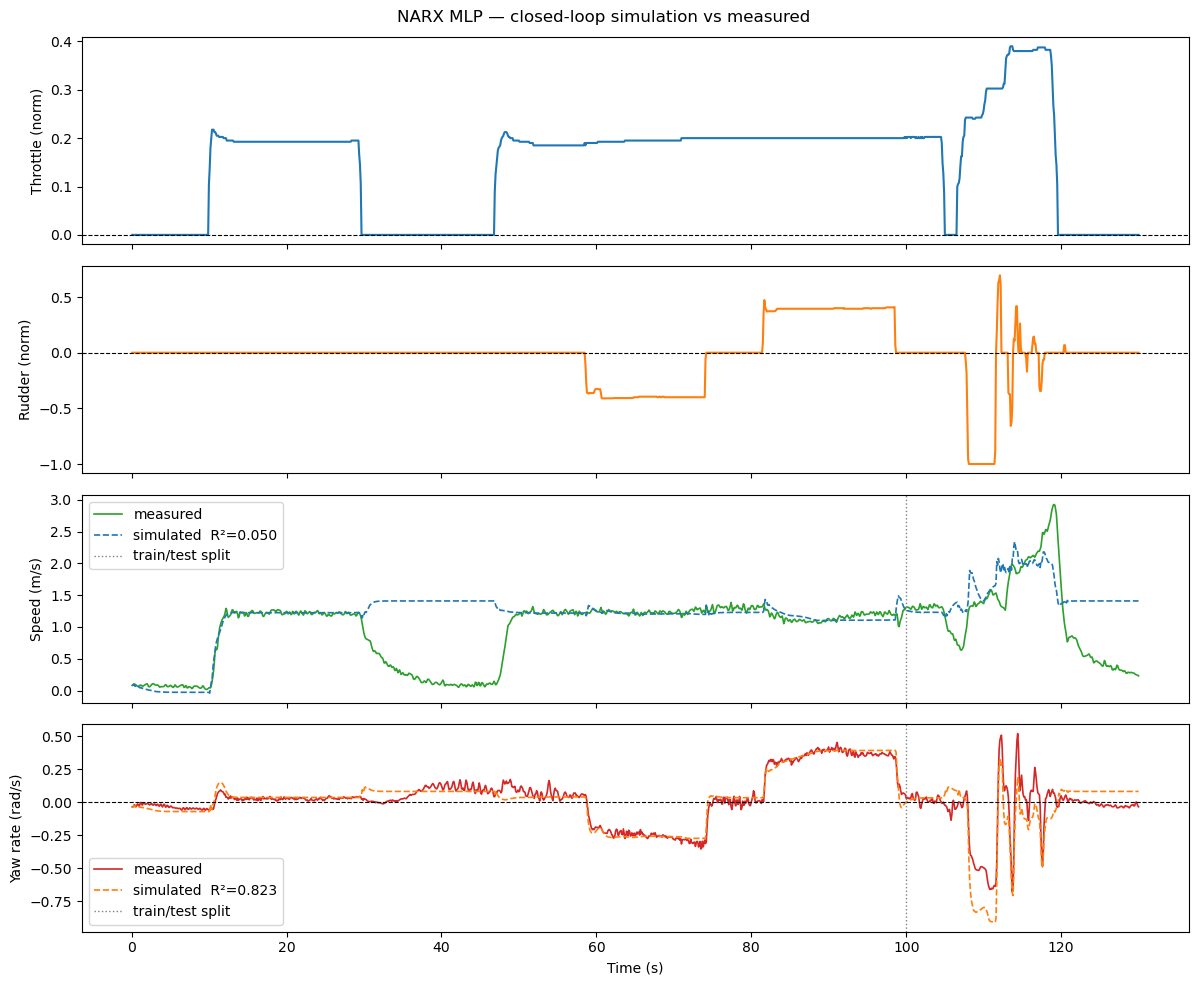

In [6]:
fig, axes = plt.subplots(4, 1, figsize=(12, 10), sharex=True)
fig.suptitle('NARX MLP — closed-loop simulation vs measured', fontsize=12)

axes[0].plot(t, u,     color='C0'); axes[0].set_ylabel('Throttle (norm)')
axes[0].axhline(0, color='k', lw=0.8, ls='--')

axes[1].plot(t, delta, color='C1'); axes[1].set_ylabel('Rudder (norm)')
axes[1].axhline(0, color='k', lw=0.8, ls='--')

axes[2].plot(t, v,     color='C2', lw=1.2, label='measured')
axes[2].plot(t, v_sim, color='C0', lw=1.2, ls='--', label=f'simulated  R²={r2_v:.3f}')
axes[2].axvline(TRAIN_END, color='gray', lw=1, ls=':', label='train/test split')
axes[2].set_ylabel('Speed (m/s)'); axes[2].legend()

axes[3].plot(t, r,     color='C3', lw=1.2, label='measured')
axes[3].plot(t, r_sim, color='C1', lw=1.2, ls='--', label=f'simulated  R²={r2_r:.3f}')
axes[3].axvline(TRAIN_END, color='gray', lw=1, ls=':', label='train/test split')
axes[3].axhline(0, color='k', lw=0.8, ls='--')
axes[3].set_ylabel('Yaw rate (rad/s)'); axes[3].legend()
axes[3].set_xlabel('Time (s)')

plt.tight_layout()
plt.show()

## 5. Three-model comparison

Summary of closed-loop simulation performance across all three model levels.
All models are evaluated on the same full dataset with the same initial conditions.

In [7]:
results = [
    ('First-order SISO',      0.9295, 0.8261),
    ('Nonlinear state-space', 0.9086, 0.8198),
    ('NARX MLP (1-step)',     r2_1step_v, r2_1step_r),
    ('NARX MLP (simulation)', r2_v,       r2_r),
]

print(f'{"Model":<28s}  {"R² speed":>10s}  {"R² yaw":>10s}')
print('-' * 54)
for name, rv, rr in results:
    print(f'{name:<28s}  {rv:>10.4f}  {rr:>10.4f}')

print()
print('Key finding: one-step vs simulation gap')
print('-' * 54)
print(f'NARX one-step speed R²   : {r2_1step_v:.4f}  (uses measured history)')
print(f'NARX simulation speed R² : {r2_v:.4f}  (propagates own predictions)')
print()
print('The NARX model predicts one step ahead well but diverges in')
print('closed-loop simulation — errors in the predicted speed compound')
print('because the model encounters states outside its training distribution.')
print('Yaw rate is less affected because it reverts to zero when rudder')
print('is neutral, limiting drift.')
print()
print('This illustrates a core advantage of the structured models: physical')
print('constraints (stable poles, energy dissipation) prevent simulation drift')
print('even on a small dataset. With more data covering the full operating')
print('envelope, the NARX model is expected to close this gap.')


Model                           R² speed      R² yaw
------------------------------------------------------
First-order SISO                  0.9295      0.8261
Nonlinear state-space             0.9086      0.8198
NARX MLP (1-step)                 0.9269      0.8763
NARX MLP (simulation)             0.0501      0.8225

Key finding: one-step vs simulation gap
------------------------------------------------------
NARX one-step speed R²   : 0.9269  (uses measured history)
NARX simulation speed R² : 0.0501  (propagates own predictions)

The NARX model predicts one step ahead well but diverges in
closed-loop simulation — errors in the predicted speed compound
because the model encounters states outside its training distribution.
Yaw rate is less affected because it reverts to zero when rudder
is neutral, limiting drift.

This illustrates a core advantage of the structured models: physical
constraints (stable poles, energy dissipation) prevent simulation drift
even on a small dataset. With 